# Telco Churn Logistic Regression Classifier 


## Data Description

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.The raw data contains 7043 rows (customers) and 21 columns (features).
The “Churn” column is our target.

## Framing The Problem 

The Telco customer churn dataset will be used to build a supervised binary classification model that predicts the probability of costumer. A train-test split will be used to assess generalization, and relevant accuracy and probability-based metrics will be analyzed. Regularization and hyperparameter tuning will be applied to optimize model performance and prevent overfitting. Decision thresholds will be adjusted to align with business risk tolerance. The final model will then be used to recommend actionable retention strategy. 

## Loading Data Set

In [1]:
# Commomn Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Raw Data Uploaded To Notebook as raw data to be cleaned 
telco = pd.read_csv("telco_churn.csv")

# Copy of origional data made to have record of origional set for referencing copy will be used for model building
telco_raw = telco.copy()
telco_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning 

In [3]:
# Checking data set for null values
telco_raw.isnull().sum().head()

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

In [4]:
# Cheking for blank strings that may not have been imputed as NAN 
(telco_raw == ' ').sum().tail(3)

MonthlyCharges     0
TotalCharges      11
Churn              0
dtype: int64

In [5]:
# Changing Empty Strings from Total Charges into NAN
telco_raw['TotalCharges'] = (telco_raw['TotalCharges'].replace(" ", np.nan))

# Asessing NAN Total Charges -- 11 total instances
telco_raw[telco_raw['TotalCharges'].isnull()].head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No


In [6]:
# NAN values for Total Charges shows new customers that have 0 tenure -- values removed
telco_raw = telco_raw.dropna()

In [7]:
# Changing TotalCharges dtype to numeric
telco_raw['TotalCharges'] = pd.to_numeric(telco_raw['TotalCharges'])

In [8]:
# Chaging Senior Citizen to categorical
telco_raw['SeniorCitizen'] = telco_raw['SeniorCitizen'].astype('category')

In [9]:
# Changing Churn from string to binary 
telco_raw['Churn'] = telco_raw['Churn'].str.strip().str.capitalize()
telco_raw['Churn'] = telco_raw['Churn'].map({'No': 0, 'Yes': 1})

## Exploratory Data Analysis

In [10]:
# Target proportion relative to total data set
round(telco_raw['Churn'].value_counts(normalize = True) * 100, 2)

Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

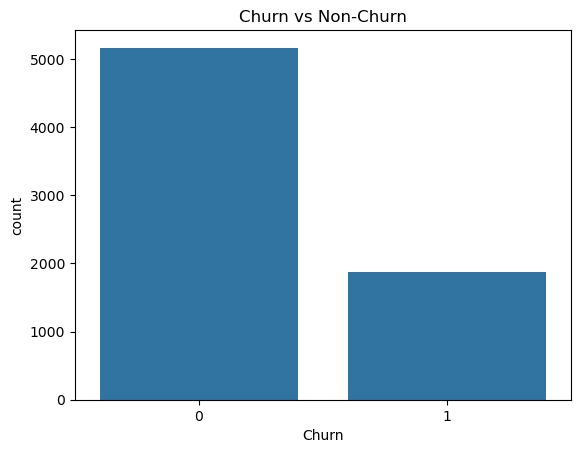

In [11]:
# Class imbalance identified
sns.countplot(x='Churn', data= telco_raw)
plt.title("Churn vs Non-Churn")
plt.show()

In [12]:
# Overall distribution of numerical data for the telco dataset
numeric_features = telco_raw.select_dtypes(include=['int64','float64']).drop(columns = 'Churn').columns
telco_raw[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


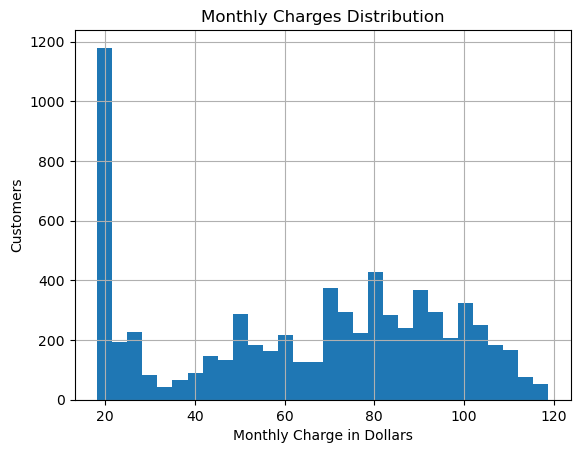

In [13]:
# The histogram for monthly charges shows heavy concetration around the 20 dollar monthly charge
telco_raw['MonthlyCharges'].hist(bins = 30)
plt.title('Monthly Charges Distribution')
plt.ylabel('Customers')
plt.xlabel('Monthly Charge in Dollars')
plt.show()

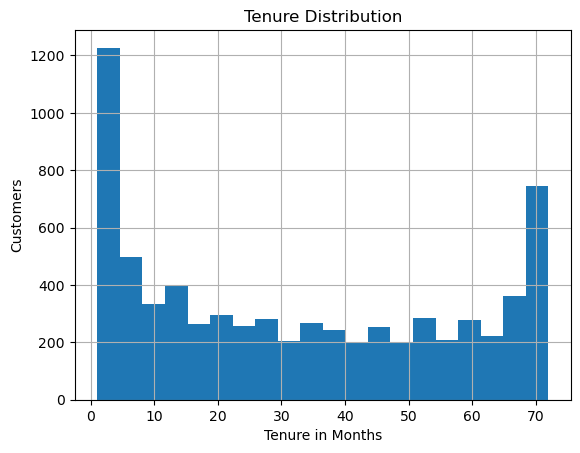

In [14]:
# Histogram of customer tenure shows high number of recently aquired customers and a subtantial amount of long-term customers
telco_raw['tenure'].hist(bins = 20)
plt.title('Tenure Distribution')
plt.ylabel('Customers')
plt.xlabel('Tenure in Months')
plt.show()

C:\Users\steve\AppData\Local\Temp\ipykernel_30452\2586251726.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = telco_raw.groupby('tenure_bin')['Churn'].mean()


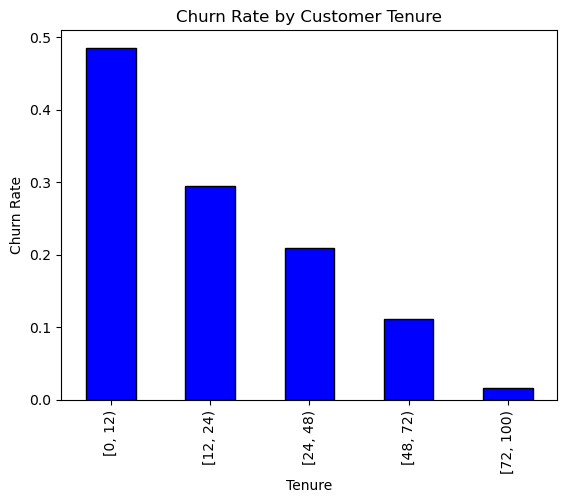

In [15]:
# Binning the Customers inorder to determine churn rate by tenure
# Tenure bins
telco_raw['tenure_bin'] = pd.cut(telco_raw['tenure'], bins=[0,12,24,48,72,100], right=False)
telco_raw['tenure_bin'] = telco_raw['tenure_bin'].astype('category')

# Compute churn rate per bin
churn_rate = telco_raw.groupby('tenure_bin')['Churn'].mean()

# Visualize churn rate
churn_rate.plot(kind='bar', color='blue', edgecolor='black')
plt.xlabel("Tenure")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Customer Tenure")
plt.show()

# There is a stedy deacrese in the churn rate as tenure rises--- focus on early retention initiatives to decrease early customer churn

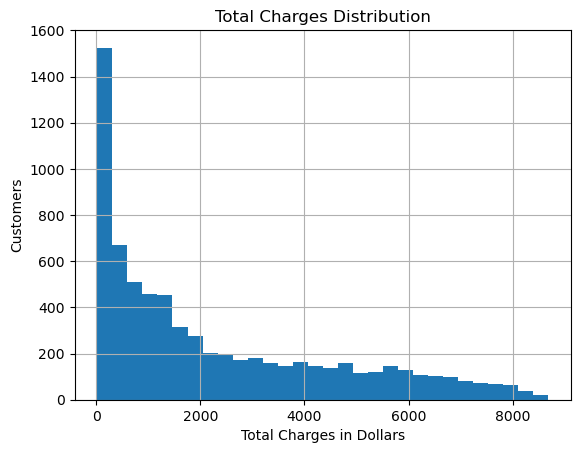

In [16]:
# Total Charges trend shows a high concentration of customers with low total charges
# This remains consitent with the increase in new customers with low monthly payments and low tenure
telco_raw['TotalCharges'].hist(bins = 30)
plt.title('Total Charges Distribution')
plt.ylabel('Customers')
plt.xlabel('Total Charges in Dollars')
plt.show()

In [17]:
# Proportions for categorical data
cat_features = telco_raw.select_dtypes(include = ['object']).drop(columns = ['customerID']).columns
for col in cat_features:
    print(round(telco[col].value_counts(normalize = True) * 100, 0))

gender
Male      50.0
Female    50.0
Name: proportion, dtype: float64
Partner
No     52.0
Yes    48.0
Name: proportion, dtype: float64
Dependents
No     70.0
Yes    30.0
Name: proportion, dtype: float64
PhoneService
Yes    90.0
No     10.0
Name: proportion, dtype: float64
MultipleLines
No                  48.0
Yes                 42.0
No phone service    10.0
Name: proportion, dtype: float64
InternetService
Fiber optic    44.0
DSL            34.0
No             22.0
Name: proportion, dtype: float64
OnlineSecurity
No                     50.0
Yes                    29.0
No internet service    22.0
Name: proportion, dtype: float64
OnlineBackup
No                     44.0
Yes                    34.0
No internet service    22.0
Name: proportion, dtype: float64
DeviceProtection
No                     44.0
Yes                    34.0
No internet service    22.0
Name: proportion, dtype: float64
TechSupport
No                     49.0
Yes                    29.0
No internet service    22.0
Name

In [18]:
# Cross Table of Dependet data with Churn data -- customers with no dependents are more likley to churn
dependent_ct = pd.crosstab(telco_raw['Dependents'], 
                           telco_raw['Churn'], 
                           normalize = 'index')
dependent_percent = (dependent_ct * 100).round(0)
print(dependent_percent)

Churn          0     1
Dependents            
No          69.0  31.0
Yes         84.0  16.0


In [19]:
# Contract Cross-table -- Month-to-Month customers are the most likley to churn 
contract_ct = pd.crosstab(telco_raw['Contract'], 
                           telco_raw['Churn'], 
                           normalize = 'index')
contract_percent = (contract_ct * 100).round(0)
print(contract_percent)

Churn              0     1
Contract                  
Month-to-month  57.0  43.0
One year        89.0  11.0
Two year        97.0   3.0


In [20]:
# Payment Method cross table -- customers paying with electronic checks are most likley to churn
payment_ct = pd.crosstab(telco_raw['PaymentMethod'], 
                          telco_raw['Churn'], 
                          normalize = 'index')
payment_percent = (payment_ct * 100).round(0)
print(payment_percent)

Churn                         0     1
PaymentMethod                        
Bank transfer (automatic)  83.0  17.0
Credit card (automatic)    85.0  15.0
Electronic check           55.0  45.0
Mailed check               81.0  19.0


In [21]:
# Internet Service cross table -- customers using the fiber optic internet service are most likley to churn
service_ct = pd.crosstab(telco_raw['InternetService'], 
                          telco_raw['Churn'], 
                          normalize = 'index')
service_percent = (service_ct * 100).round(0)
print(service_percent)

Churn               0     1
InternetService            
DSL              81.0  19.0
Fiber optic      58.0  42.0
No               93.0   7.0


Text(0.5, 1.0, 'Numeric Correlation Matrix')

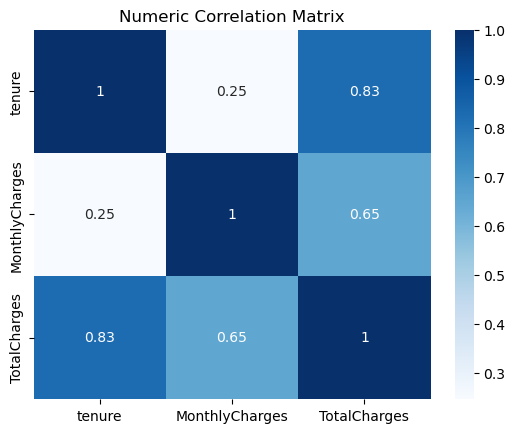

In [22]:
# Correaltion Matrix of numerical feauters -- high correlation between total charge and tenure
# Due to Total Charge being derived from montly charge x tenure it will be removed to reduce multicolinearity
corr = telco_raw[numeric_features].corr()
sns.heatmap(corr, annot = True, cmap = 'Blues')
plt.title('Numeric Correlation Matrix')

## Feauture Engineering

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [24]:
# Removing columns that are unecessary for modeling due to multicolinearity, redundancy, and lack of application
telco_clean = telco_raw.drop(columns = ['customerID', 'tenure', 'TotalCharges'])
X = telco_clean.drop(columns = 'Churn')
y = telco_clean['Churn']

In [25]:
# Seperating numeric features from categorical features and saving as variable to use in preprocessor
numeric_features = ['MonthlyCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

In [26]:
# Preprocessor buld with Standard Scaler for numeric columns and One Hot Encoding for categorical columns
preprocessor = ColumnTransformer([ ('num', StandardScaler(), numeric_features),  
                                  ('cat', OneHotEncoder(drop = 'first', handle_unknown='ignore'), categorical_features)
                                ])

In [27]:
# Pipeline is built with a logistic regession class set to random state 42 for reproducibility
# Class weight in regressor balanced in order to extract optimal signaling from 'Yes' y classification that is only 26% of the data
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([('preprocessor', preprocessor),
                     ('classifier', LogisticRegression(class_weight = 'balanced', random_state = 42))])

## Train-Test Split

In [28]:
# Data was split into features and target
y = telco_clean['Churn']
X = telco_clean.drop(columns = ['Churn'])

# Train test split with 20% test size and straify 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# Fitting the training data to the pipeline, the tranforming the train data making sure not to fit to avoid data leaks
log_pipeline.fit(X_train, y_train)
y_pred = log_pipeline.predict(X_test)

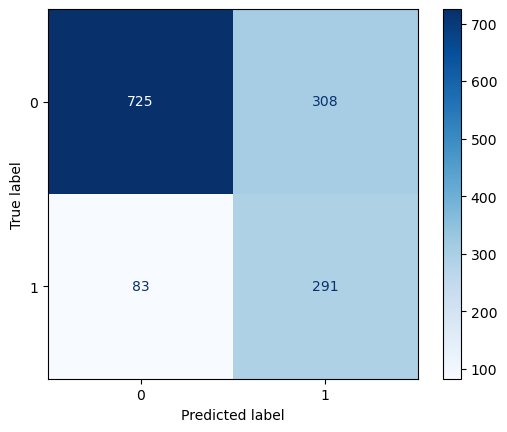

In [30]:
# Confusion matrix for predicitons 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_pipeline.classes_)
disp.plot(cmap='Blues')

In [31]:
from sklearn.metrics import accuracy_score , f1_score

# AUC used to measure feature siganling. Signal over 0.5 demostrates significant feature signaling
from sklearn.metrics import roc_auc_score
y_proba = log_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print("ROC_AUC:", auc)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

ROC_AUC: 0.8280849609931098
Accuracy: 0.7221037668798863
F1 Score: 0.5981500513874615


## Regularization

In [32]:
from sklearn.model_selection import GridSearchCV

# Grid that will be used to find best params
# L2 (Ridge) penalty to reduce coreelated feature but maintain all features
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],   
    'classifier__solver': ['liblinear']
             }

# Fitting the grid to the logisitic regression base model
grid = GridSearchCV(log_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV F1: 0.6328285226893725


In [33]:
# Saving the best model for use on training data 
best_model = grid.best_estimator_

#New Pipeline 
best_pipeline = Pipeline([('preprocessor', preprocessor), 
                          ('classifier', LogisticRegression(C = 100, 
                                                            penalty = 'l2', 
                                                            class_weight = 'balanced', 
                                                            solver = 'liblinear', 
                                                            random_state = 42))])

# Fit best model on data 
best_pipeline.fit(X_train, y_train)

# Predict using best data 
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:,1]

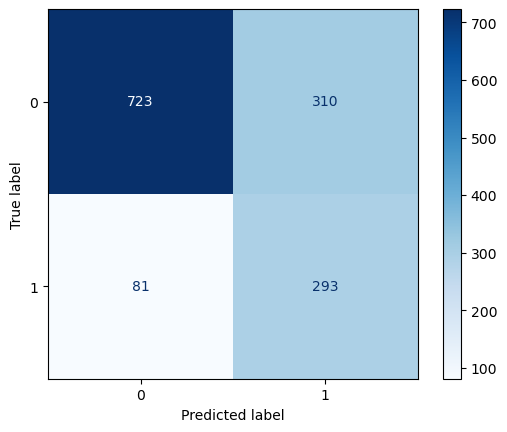

In [34]:
# Confusion Matrix for Best Model
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_pipeline.classes_)
disp.plot(cmap='Blues')

In [35]:
# Evaluation Metrics for Best Model
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best))

F1 Score: 0.5997952917093142
ROC-AUC: 0.7416628272359723


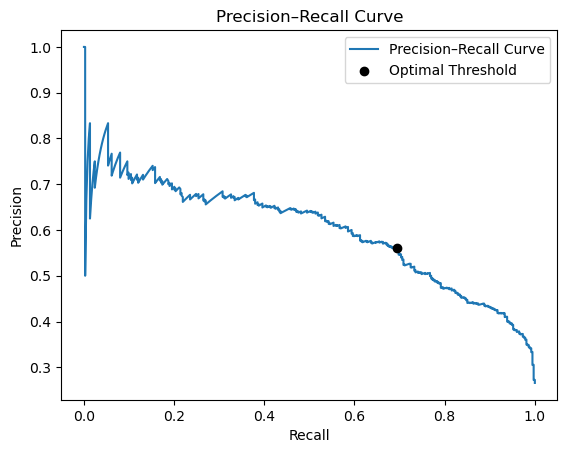

In [36]:
# Recall/ Precision Curve plotted to chose the best recall-optimized threshold for churn detection
# Recall will be prioritized will monitoring for acceptable precision trade-offs

from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best, pos_label = 1 )

# F1 score calculation (removed last point to line up with thresholds)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

# Plotted Precision-Recall Curve with most optimal F1 score 
plt.figure()
plt.plot(recall, precision, label="Precision–Recall Curve")
plt.scatter(recall[best_idx], precision[best_idx], label="Optimal Threshold", zorder=5, color = 'black')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

### Optimized Threshold for Max F1 Score

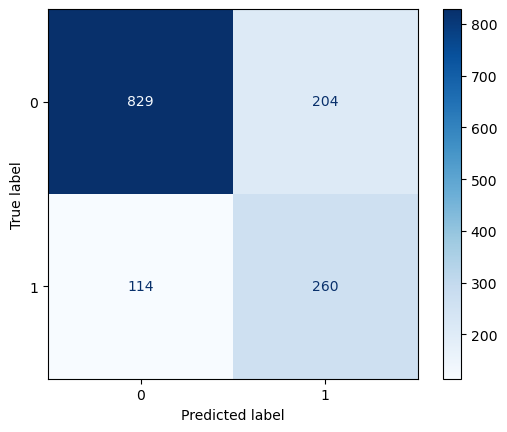

In [37]:
# Best Threshold Confusion Matrix 
y_pred_opt = (y_proba_best >= best_threshold).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt,
                              display_labels=best_pipeline.classes_)
disp.plot(cmap='Blues')

## Precision Optomization

Depending on stakeholder specifications, the recall rate obtained at the optimal decision threshold may be sufficient for deployment. For the purpose of demonstrating an alternative optimization strategy, it is assumed that stakeholders have indicated the company’s customer retention interventions are inexpensive and easy to scale.

As a result, stakeholders have requested that the model prioritize recall above all other metrics, with the objective of identifying as many at-risk customers as possible, even at the expense of reduced precision. This reflects a business context in which false positives (customers incorrectly flagged as likely to churn) are acceptable, while false negatives (missed churners) are significantly more costly.

Stakeholders have specified a minimum acceptable precision threshold of 40% for the final model. Therefore, the selected decision threshold will be the one that maximizes recall while ensuring precision remains at or above 40%

In [38]:
precision_40 = precision[:-1]
recall_40 = recall[:-1]
thresholds_40 = thresholds

In [39]:
# Filter for precision minimum
min_mask = precision_40 >= 0.40

# Highest recall for precisions at or abaove 40% precision
best_idx_40 = np.argmax(recall_40[min_mask])

# Best threshold given contraints
best_threshold_40 = thresholds_40[min_mask][best_idx_40]

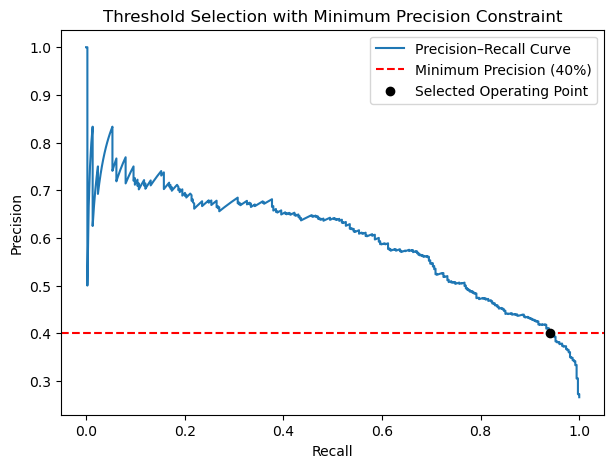

In [40]:
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label="Precision–Recall Curve")
plt.axhline(
    y= 0.40,
    color="red",
    linestyle="--",
    label="Minimum Precision (40%)"
)
plt.scatter(
    recall_40[min_mask][best_idx_40],
    precision_40[min_mask][best_idx_40],
    color="black",
    zorder=5,
    label="Selected Operating Point"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Threshold Selection with Minimum Precision Constraint")
plt.show()


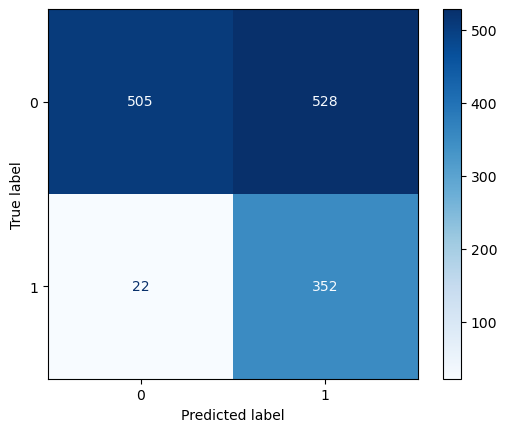

In [41]:
# Best Threshold Confusion Matrix 
y_pred_40 = (y_proba_best >= best_threshold_40).astype(int)

cm_40 = confusion_matrix(y_test, y_pred_40)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_40,
                              display_labels=best_pipeline.classes_)
disp.plot(cmap='Blues')

In [42]:
# Evaluation Metrics for Best Model -- F1 slight drop but huge increase in recall
print("F1 Score:", f1_score(y_test, y_pred_40))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_40))

F1 Score: 0.5614035087719298
ROC-AUC: 0.7150219235806616


### Business Interpretation and Actionable Recommendations

In [43]:
# Creating a DF that includes all features and their coefficients
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_pipeline.named_steps['classifier'].coef_[0]

important_features = pd.DataFrame({'Feature': feature_names, 
                                  'Coefficient': coefficients}
                                ).sort_values(by = 'Coefficient', ascending = False)

In [44]:
# Largest positive coefficients show that fiber optic, TV streaming, and Movie streaming services increse the probability of churn 
important_features.head(3)

,Feature,Coefficient
8,cat__InternetService_Fiber optic,2.534217
19,cat__StreamingTV_Yes,0.963352
21,cat__StreamingMovies_Yes,0.955928
7,cat__MultipleLines_Yes,0.645113
26,cat__PaymentMethod_Electronic check,0.410963


In [45]:
 ''' Largest negative coefficients are consitent in showing that the most engaged and tenured customers are going to be 
the least likley to churn. '''
important_features.tail(3)

,Feature,Coefficient
23,cat__Contract_Two year,-1.695485
0,num__MonthlyCharges,-1.981991
31,"cat__tenure_bin_[72, 100)",-2.611949


The model identified fiber optic internet and streaming service subscriptions as strong predictors of churn. Given that these represent higher-tier service offerings, this may indicate dissatisfaction related to service quality, outages, or pricing perception. A targeted audit of fiber performance metrics and streaming bundle value is recommended. Additionally, implementing proactive retention strategies for customers within this segment could reduce churn among high-revenue users.